<a href="https://colab.research.google.com/github/imrosie/banking-telesales-marketing-optimization/blob/main/Stage_3_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pickle
from pathlib import Path

%matplotlib inline
matplotlib.style.use('ggplot')

In [ ]:
df_train = pd.read_csv('https://raw.githubusercontent.com/ChangCorp/finalproject/main/train_delimited_comma.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/ChangCorp/finalproject/main/test_delimited_comma.csv')

In [ ]:
# mengubah nama kolom 'y' menjadi 'subscribed' untuk menghindari kebingungan saat modeling dan validation
df_train=df_train.rename(columns = {'y':'subscribed'})
df_test=df_test.rename(columns = {'y':'subscribed'})

# Preprocessing

In [ ]:
# Handle Missing Values


# Training - Nilai unknown pada `job` berubah menyesuaikan data `education`
# RUMPANG NOMOR 7
df_train.loc[(df_train.job == "unknown") & (df_train.education == "primary"),"job"] = "blue-collar"
df_train.loc[(df_train.job == "unknown") & (df_train.education == "secondary"),"job"] = "blue-collar"
df_train.loc[(df_train.job == "unknown") & (df_train.education == "tertiary"),"job"] = "management"
df_train.loc[(df_train.job == "unknown") & (df_train.education == "unknown"),"job"] = "blue-collar"

# Training - Nilai unknown pada `education` berubah menyesuaikan data modus pada `job`
df_train.loc[(df_train.education == "unknown") & (df_train.job == "admin."),"education"] = "secondary"
df_train.loc[(df_train.education == "unknown") & (df_train.job == "blue-collar"),"education"] = "secondary"
df_train.loc[(df_train.education == "unknown") & (df_train.job == "entrepreneur"),"education"] = "tertiary"
df_train.loc[(df_train.education == "unknown") & (df_train.job == "housemaid"),"education"] = "primary"
df_train.loc[(df_train.education == "unknown") & (df_train.job == "management"),"education"] = "tertiary"
df_train.loc[(df_train.education == "unknown") & (df_train.job == "retired"),"education"] = "secondary"
df_train.loc[(df_train.education == "unknown") & (df_train.job == "self-employed"),"education"] = "tertiary"
df_train.loc[(df_train.education == "unknown") & (df_train.job == "services"),"education"] = "secondary"
df_train.loc[(df_train.education == "unknown") & (df_train.job == "student"),"education"] = "secondary"
df_train.loc[(df_train.education == "unknown") & (df_train.job == "technician"),"education"] = "secondary"
df_train.loc[(df_train.education == "unknown") & (df_train.job == "unemployed"),"education"] = "secondary"
df_train.loc[(df_train.education == "unknown"),"education"] = "secondary"

# Training - Nilai unknown pada `contact` berubah menyesuaikan data modus
df_train["contact"].replace(["unknown"],df_train["contact"].mode(),inplace = True)

# Testing - Nilai unknown pada `job` berubah menyesuaikan data `education`, mengikuti rules dataset Train
df_test.loc[(df_test.job == "unknown") & (df_test.education == "primary"),"job"] = "blue-collar"
df_test.loc[(df_test.job == "unknown") & (df_test.education == "secondary"),"job"] = "blue-collar"
df_test.loc[(df_test.job == "unknown") & (df_test.education == "tertiary"),"job"] = "management"
df_test.loc[(df_test.job == "unknown") & (df_test.education == "unknown"),"job"] = "blue-collar"

# Testing = Nilai unknown pada `education` berubah menyesuaikan data modus pada `job`, mengikuti rules dataset Train
df_test.loc[(df_test.education == "unknown") & (df_test.job == "admin."),"education"] = "secondary"
df_test.loc[(df_test.education == "unknown") & (df_test.job == "blue-collar"),"education"] = "secondary"
df_test.loc[(df_test.education == "unknown") & (df_test.job == "entrepreneur"),"education"] = "tertiary"
df_test.loc[(df_test.education == "unknown") & (df_test.job == "housemaid"),"education"] = "primary"
df_test.loc[(df_test.education == "unknown") & (df_test.job == "management"),"education"] = "tertiary"
df_test.loc[(df_test.education == "unknown") & (df_test.job == "retired"),"education"] = "secondary"
df_test.loc[(df_test.education == "unknown") & (df_test.job == "self-employed"),"education"] = "tertiary"
df_test.loc[(df_test.education == "unknown") & (df_test.job == "services"),"education"] = "secondary"
df_test.loc[(df_test.education == "unknown") & (df_test.job == "student"),"education"] = "secondary"
df_test.loc[(df_test.education == "unknown") & (df_test.job == "technician"),"education"] = "secondary"
df_test.loc[(df_test.education == "unknown") & (df_test.job == "unemployed"),"education"] = "secondary"
df_test.loc[(df_test.education == "unknown"),"education"] = "secondary"

# Testing - Nilai unknown pada `contact` berubah menyesuaikan data modus

df_test["contact"].replace(["unknown"],df_test["contact"].mode(),inplace = True)

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
df_train['balance_norm']=MinMaxScaler().fit_transform(df_train['balance'].values.reshape(len(df_train),1))
# df_train['balance_std']=StandardScaler().fit_transform(df_train['balance'].values.reshape(len(df_train),1))

In [ ]:
# MinMax Scaler for Normalization df_test
fit = MinMaxScaler().fit(df_train['balance'].values.reshape(len(df_train),1)) # fit using parameters from df_train
df_test['balance_norm'] = fit.transform(df_test['balance'].values.reshape(len(df_test),1))
print(df_test[['balance','balance_norm']].describe())
print('')

            balance  balance_norm
count   4521.000000   4521.000000
mean    1422.657819      0.085719
std     3009.638142      0.027324
min    -3313.000000      0.042725
25%       69.000000      0.073430
50%      444.000000      0.076834
75%     1480.000000      0.086240
max    71188.000000      0.719109



In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df_train['pp_age_norm'] = MinMaxScaler().fit_transform(df_train['age'].values.reshape(len(df_train),1))

In [ ]:
# MinMax Scaler for Normalization df_test

fit = MinMaxScaler().fit(df_train['age'].values.reshape(len(df_train),1)) # fit using parameters from df_train
df_test['pp_age_norm'] = fit.transform(df_test['age'].values.reshape(len(df_test),1))
print(df_test[['age','pp_age_norm']].describe())
print('')

               age  pp_age_norm
count  4521.000000  4521.000000
mean     41.170095     0.300910
std      10.576211     0.137353
min      19.000000     0.012987
25%      33.000000     0.194805
50%      39.000000     0.272727
75%      49.000000     0.402597
max      87.000000     0.896104



In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
df_train['campaign_norm']=MinMaxScaler().fit_transform(df_train['campaign'].values.reshape(len(df_train),1))
# df_train['balance_std']=StandardScaler().fit_transform(df_train['balance'].values.reshape(len(df_train),1))

In [ ]:
# MinMax Scaler for Normalization df_test
fit = MinMaxScaler().fit(df_train['campaign'].values.reshape(len(df_train),1)) # fit using parameters from df_train
df_test['campaign_norm'] = fit.transform(df_test['campaign'].values.reshape(len(df_test),1))
print(df_test[['campaign','campaign_norm']].describe())
print('')

          campaign  campaign_norm
count  4521.000000    4521.000000
mean      2.793630       0.028930
std       3.109807       0.050158
min       1.000000       0.000000
25%       1.000000       0.000000
50%       2.000000       0.016129
75%       3.000000       0.032258
max      50.000000       0.790323



In [ ]:
def segment(x) :
    if x['previous'] == 0 :
        hasil = 0
    elif x['previous'] > 0  :
        hasil = 1
    return hasil

df_train['ever_contacted'] = df_train.apply(lambda x : segment(x), axis=1) # RUMPANG 9
df_test['ever_contacted'] = df_test.apply(lambda x : segment(x), axis=1) # RUMPANG 9

In [ ]:
# Label Encoding - df_train (untuk feature dengan distinct values 2, atau tipe ordinal)

# Encoding - Education (Tipe ordinal - punya urutan)
df_train.loc[(df_train.education == "tertiary"),"education"] = 2
df_train.loc[(df_train.education == "secondary") ,"education"] = 1
df_train.loc[(df_train.education == "primary"),"education"] = 0

# Encoding - Default
df_train.loc[(df_train.default == "yes"),"default"] = 1
df_train.loc[(df_train.default == "no") ,"default"] = 0

# Encoding - Housing
df_train.loc[(df_train.housing == "yes"),"housing"] = 1
df_train.loc[(df_train.housing == "no") ,"housing"] = 0

# Encoding - Loan
df_train.loc[(df_train.loan == "yes"),"loan"] = 1
df_train.loc[(df_train.loan == "no") ,"loan"] = 0

# Encoding - Contact
df_train.loc[(df_train.contact == "telephone"),"contact"] = 1
df_train.loc[(df_train.contact == "cellular") ,"contact"] = 0

# Encoding - Poutcome
df_train.loc[(df_train.poutcome == "success"),"poutcome_success"] = 1
df_train.loc[(df_train.poutcome == "unknown") ,"poutcome_success"] = 0
df_train.loc[(df_train.poutcome == "failure") ,"poutcome_success"] = 0
df_train.loc[(df_train.poutcome == "other") ,"poutcome_success"] = 0

# Encoding - Subscribed
df_train.loc[(df_train.subscribed == "yes"),"subscribed"] = 1
df_train.loc[(df_train.subscribed == "no") ,"subscribed"] = 0

# Encoding - Marital
df_train.loc[(df_train.marital == "married"),"is_married"] = 1
df_train.loc[(df_train.marital == "single") ,"is_married"] = 0
df_train.loc[(df_train.marital == "divorced"),"is_married"] = 0

# Adjusting data type
df_train.education = df_train.education.astype(int)
df_train.default = df_train.default.astype(int)
df_train.housing = df_train.housing.astype(int)
df_train.loan = df_train.loan.astype(int)
df_train.contact = df_train.contact.astype(int)
df_train.poutcome_success = df_train.poutcome_success.astype(int)
df_train.subscribed = df_train.subscribed.astype(int)
df_train.is_married = df_train.is_married.astype(int)

In [ ]:
# Label Encoding - df_test (untuk feature dengan distinct values 2, atau tipe ordinal)

# Encoding - Education (Tipe ordinal - punya urutan)
df_test.loc[(df_test.education == "tertiary"),"education"] = 2
df_test.loc[(df_test.education == "secondary") ,"education"] = 1
df_test.loc[(df_test.education == "primary"),"education"] = 0

# Encoding - Default
df_test.loc[(df_test.default == "yes"),"default"] = 1
df_test.loc[(df_test.default == "no") ,"default"] = 0

# Encoding - Housing
df_test.loc[(df_test.housing == "yes"),"housing"] = 1
df_test.loc[(df_test.housing == "no") ,"housing"] = 0

# Encoding - Loan
df_test.loc[(df_test.loan == "yes"),"loan"] = 1
df_test.loc[(df_test.loan == "no") ,"loan"] = 0

# Encoding - Contact
df_test.loc[(df_test.contact == "telephone"),"contact"] = 1
df_test.loc[(df_test.contact == "cellular") ,"contact"] = 0

# Encoding - Poutcome
df_test.loc[(df_test.poutcome == "success"),"poutcome_success"] = 1
df_test.loc[(df_test.poutcome == "unknown") ,"poutcome_success"] = 0
df_test.loc[(df_test.poutcome == "failure") ,"poutcome_success"] = 0
df_test.loc[(df_test.poutcome == "other") ,"poutcome_success"] = 0

# Encoding - Subscribed
df_test.loc[(df_test.subscribed == "yes"),"subscribed"] = 1
df_test.loc[(df_test.subscribed == "no") ,"subscribed"] = 0

# Encoding - Marital
df_test.loc[(df_test.marital == "married"),"is_married"] = 1
df_test.loc[(df_test.marital == "single") ,"is_married"] = 0
df_test.loc[(df_test.marital == "divorced"),"is_married"] = 0

# Adjusting Data Type
df_test.education = df_test.education.astype(int)
df_test.default = df_test.default.astype(int)
df_test.housing = df_test.housing.astype(int)
df_test.loan = df_test.loan.astype(int)
df_test.contact = df_test.contact.astype(int)
df_test.poutcome_success = df_test.poutcome_success.astype(int)
df_test.subscribed = df_test.subscribed.astype(int)
df_test.is_married = df_test.is_married.astype(int)

In [ ]:
# Job - df_train

# Job Group (Feature Extraction - Job Group first to reduce distinct values, some jobs are similar)
df_train.loc[df_train['job']=='blue-collar', 'job_group'] = 'blue_collar'
df_train.loc[df_train['job']=='technician', 'job_group'] = 'blue_collar'
df_train.loc[df_train['job']=='admin.', 'job_group'] = 'blue_collar'
df_train.loc[df_train['job']=='services', 'job_group'] = 'blue_collar'
df_train.loc[df_train['job']=='housemaid', 'job_group'] = 'blue_collar'
df_train.loc[df_train['job']=='management', 'job_group'] = 'management'
df_train.loc[df_train['job']=='self-employed', 'job_group'] = 'entrepreneur'
df_train.loc[df_train['job']=='entrepreneur', 'job_group'] = 'entrepreneur'
df_train.loc[df_train['job']=='unemployed', 'job_group'] = 'unemployed'
df_train.loc[df_train['job']=='student', 'job_group'] = 'student'
df_train.loc[df_train['job']=='retired', 'job_group'] = 'retired'

# OHE
df_train[['job_blue_collar','job_entrepreneur','job_management','job_retired','job_student','job_unemployed']] = pd.get_dummies(df_train['job_group'],prefix='job')

In [ ]:
# Job - df_test

# Job Group (Feature Extraction - Job Group first to reduce distinct values, some jobs are similar)
df_test.loc[df_test['job']=='blue-collar', 'job_group'] = 'blue_collar'
df_test.loc[df_test['job']=='technician', 'job_group'] = 'blue_collar'
df_test.loc[df_test['job']=='admin.', 'job_group'] = 'blue_collar'
df_test.loc[df_test['job']=='services', 'job_group'] = 'blue_collar'
df_test.loc[df_test['job']=='housemaid', 'job_group'] = 'blue_collar'
df_test.loc[df_test['job']=='management', 'job_group'] = 'management'
df_test.loc[df_test['job']=='self-employed', 'job_group'] = 'entrepreneur'
df_test.loc[df_test['job']=='entrepreneur', 'job_group'] = 'entrepreneur'
df_test.loc[df_test['job']=='unemployed', 'job_group'] = 'unemployed'
df_test.loc[df_test['job']=='student', 'job_group'] = 'student'
df_test.loc[df_test['job']=='retired', 'job_group'] = 'retired'

# OHE
df_test[['job_blue_collar','job_entrepreneur','job_management','job_retired','job_student','job_unemployed']] = pd.get_dummies(df_test['job_group'],prefix='job')

# Feature Selection

In [ ]:
df_train_fin = df_train[['education',
                         'housing',
                         'loan',
                         'subscribed',
                        #  'balance',
                         'balance_norm',
                        #  'age',
                         'pp_age_norm',
                        #  'campaign',
                         'campaign_norm',
                         'ever_contacted',
                         'poutcome_success',
                         'is_married',
                         'job_blue_collar',
                         'job_entrepreneur',
                         'job_management',
                         'job_retired',
                         'job_student',
                         'job_unemployed'
]]

df_test_fin = df_test[['education',
                         'housing',
                         'loan',
                         'subscribed',
                        #  'balance',
                         'balance_norm',
                        #  'age',
                         'pp_age_norm',
                        #  'campaign',
                         'campaign_norm',
                         'ever_contacted',
                         'poutcome_success',
                         'is_married',
                         'job_blue_collar',
                         'job_entrepreneur',
                         'job_management',
                         'job_retired',
                         'job_student',
                         'job_unemployed'
]]

# Modeling

DISCLAIMER: Akan digabungkan df_train dan df_test, dilakukan SMOTE, lalu di split lagi train dan testnya. Kami telah melakukan berbagai modeling dengan tahap train test split, lalu SMOTE. Nilai-nilai pada model evaluation selalu kecil, recall berkisar 0.16 - 0.4 (bahkan setelah hyperparameter tuning). Selain itu, jika menggunakan train test split yang disediakan Kaggle, modelnya terlalu overfit (accuracy, recall dll scorenya bisa > 0.95)

In [ ]:
df_all = pd.concat([df_train_fin,df_test_fin])
print('Jumlah baris duplicate: ', df_all.duplicated().sum())

Jumlah baris duplicate:  5651


In [ ]:
df_all1 = pd.concat([df_train,df_test])
print('Jumlah baris duplicate: ', df_all1.duplicated().sum())

Jumlah baris duplicate:  4521


In [ ]:
print('Jumlah baris duplicate: ', df_train_fin.duplicated().sum())

Jumlah baris duplicate:  1130


Rupanya df_test merupakan subset dari df_train. Selanjutnya, df_test tidak akan dipakai. Sebelum modeling, akan dilakukan drop duplicates.

In [ ]:
df_model = df_train_fin.drop_duplicates(keep='first')

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
import warnings
warnings.filterwarnings('ignore')

SPLIT X AND Y

definisikan variabel baru x dan y dimana x adalah semua kolom fitur dan y adalah semua kolom target

In [ ]:
X = df_model.drop(columns='subscribed', axis=1)
y = df_model['subscribed']

In [ ]:
from imblearn import under_sampling, over_sampling

x_under, y_under = under_sampling.RandomUnderSampler(sampling_strategy=0.5).fit_resample(X, y)
x_over, y_over = over_sampling.RandomOverSampler(sampling_strategy=0.5).fit_resample(X, y)
X_train_SMOTE, y_train_SMOTE = over_sampling.SMOTE(sampling_strategy=0.5).fit_resample(X, y) #yg dipakai cuma ini

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_train_SMOTE, y_train_SMOTE, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_validate

def eval_classification(model):
    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    y_pred_proba = model.predict_proba(X_test)
    y_pred_proba_train = model.predict_proba(X_train)

    print("Accuracy (Test Set): %.2f" % accuracy_score(y_test, y_pred))
    print("Precision (Test Set): %.2f" % precision_score(y_test, y_pred))
    print("Recall (Test Set): %.2f" % recall_score(y_test, y_pred))
    print("F1-Score (Test Set): %.2f" % f1_score(y_test, y_pred))

    print("roc_auc (test-proba): %.2f" % roc_auc_score(y_test, y_pred_proba[:, 1]))
    print("roc_auc (train-proba): %.2f" % roc_auc_score(y_train, y_pred_proba_train[:, 1]))

def show_feature_importance(model):
    feat_importances = pd.Series(model.feature_importances_, index=X.columns)
    ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(10, 8))
    ax.invert_yaxis()

    plt.xlabel('score')
    plt.ylabel('feature')
    plt.title('feature importance score')

def show_best_hyperparameter(model):
    print(model.best_estimator_.get_params())

## Decision Tree

Decision Tree

Menggunakan model ML Decision Tree, tampilkan hasil classification pertamanya.

In [ ]:
# decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
eval_classification(dt)

Accuracy (Test Set): 0.80
Precision (Test Set): 0.70
Recall (Test Set): 0.71
F1-Score (Test Set): 0.71
roc_auc (test-proba): 0.78
roc_auc (train-proba): 1.00


Terlihat model overfit. Akan coba dilakukan hyperparameter tuning

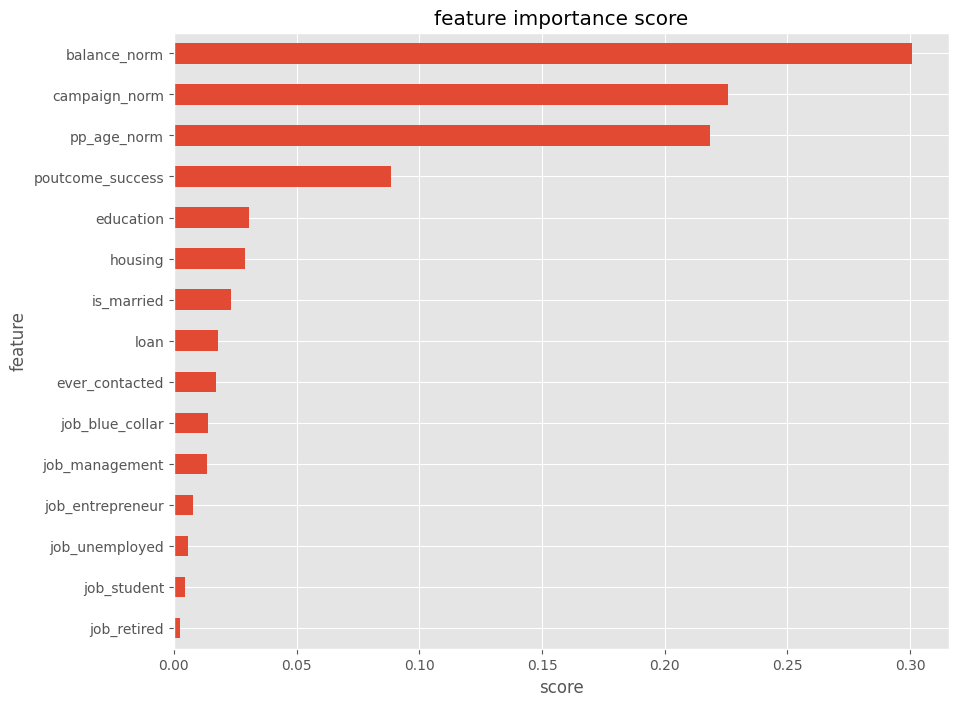

In [ ]:
show_feature_importance(dt)

HYPERPARAMETER

Perbaiki model Decision Tree yang overfit dengan :

1. parameter maksimal  = auto dan sqrt
2. menggunakan cv sebesar 5
3. menggunakan "recall" sebagai scoring

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import uniform
import numpy as np


max_depth = [int(x) for x in np.linspace(10, 110, num = 30)] # Maximum number of levels in tree
min_samples_split = [50, 100] # Minimum number of samples required to split a node
min_samples_leaf = [10, 20, 50] # Minimum number of samples required at each leaf node
max_features = ['auto', 'sqrt'] # Number of features to consider at every split
criterion = ['gini','entropy']
splitter = ['best','random']


hyperparameters = dict(max_depth=max_depth,
                       min_samples_split=min_samples_split,
                       min_samples_leaf=min_samples_leaf,
                       max_features=max_features,
                       criterion=criterion,
                       splitter=splitter
                      )

# Inisialisasi Model
dt_ht = DecisionTreeClassifier(random_state=42)
model = GridSearchCV(dt, hyperparameters, scoring = 'recall', cv = 5, n_jobs=-1)
model.fit(X_train, y_train)

# Predict & Evaluation
y_pred = model.predict(X_test)#Check performa dari model
eval_classification(model)

Accuracy (Test Set): 0.78
Precision (Test Set): 0.74
Recall (Test Set): 0.55
F1-Score (Test Set): 0.63
roc_auc (test-proba): 0.81
roc_auc (train-proba): 0.87


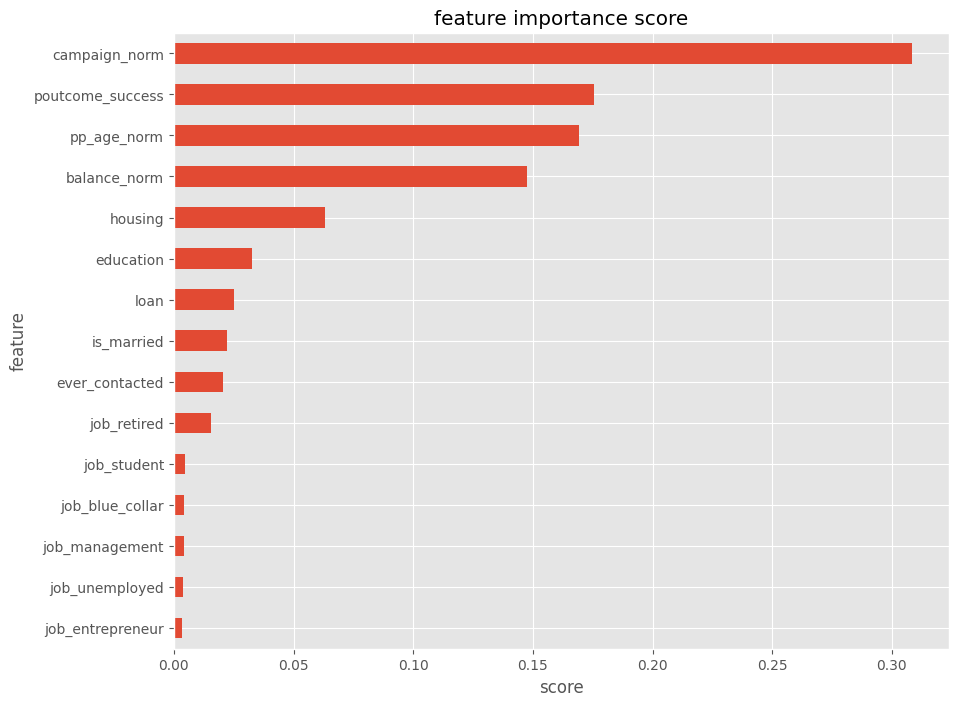

In [ ]:
show_feature_importance(model.best_estimator_)

Model tidak lagi overfit, tetapi nilai Recall menurun

## Random Forest

Random Forest

Menggunakan model ML Random Forest, tampilkan hasil classification pertamanya.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train, y_train)
eval_classification(rf)

Accuracy (Test Set): 0.84
Precision (Test Set): 0.80
Recall (Test Set): 0.70
F1-Score (Test Set): 0.75
roc_auc (test-proba): 0.89
roc_auc (train-proba): 1.00


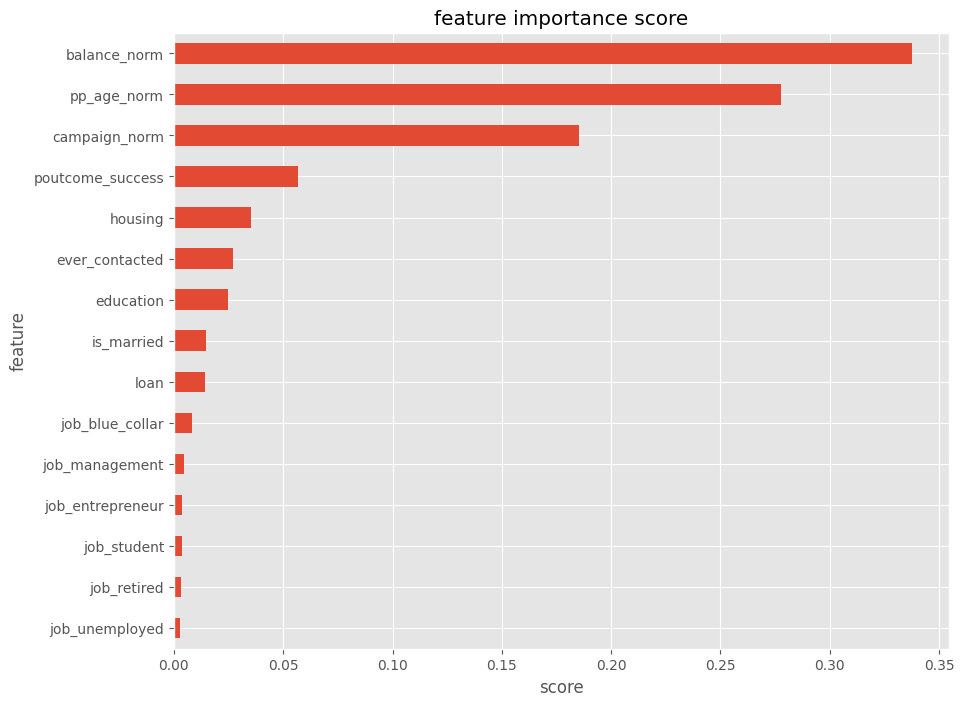

In [ ]:
show_feature_importance(rf)

In [ ]:
# tuning hyperparameter RF
from sklearn.model_selection import RandomizedSearchCV

n_estimators = [int(x) for x in np.linspace(10, 100, 50)]
criterion = ['gini', 'entropy']
max_depth = [int(x) for x in np.linspace(2, 50, 10)]
min_samples_split = [int(x) for x in np.linspace(10, 50, 10)]
min_samples_leaf = [int(x) for x in np.linspace(10, 50, 10)]
hyperparameters = dict(n_estimators=n_estimators, criterion=criterion, max_depth=max_depth,
                       min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf)

rf_hp = RandomForestClassifier(random_state=42)
rs_hp = RandomizedSearchCV(rf_hp, hyperparameters, scoring='recall', random_state=42, cv=5)
rs_hp.fit(X_train, y_train)
eval_classification(rs_hp)

Accuracy (Test Set): 0.80
Precision (Test Set): 0.82
Recall (Test Set): 0.52
F1-Score (Test Set): 0.64
roc_auc (test-proba): 0.86
roc_auc (train-proba): 0.89


Hasil hyperparameter tuning --> model tidak overfit, nilai recall turun


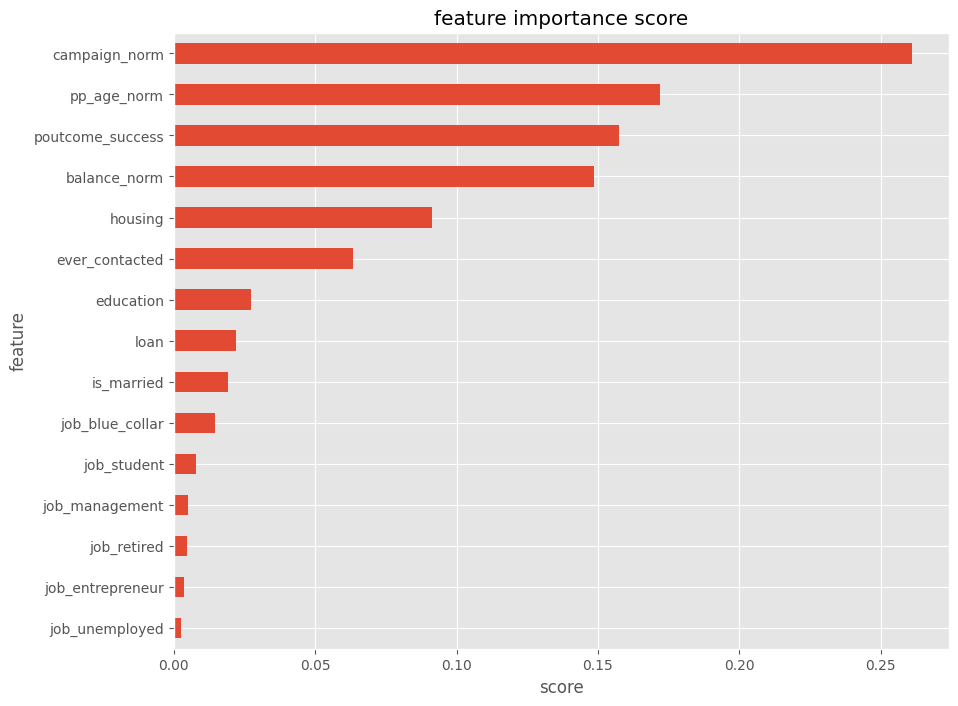

In [ ]:
show_feature_importance(rs_hp.best_estimator_)

## Logistic Regression

Logistic Regression

Menggunakan model ML Logistic Regression, tampilkan hasil classification pertamanya.

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
eval_classification(lr)

Accuracy (Test Set): 0.73
Precision (Test Set): 0.73
Recall (Test Set): 0.31
F1-Score (Test Set): 0.43
roc_auc (test-proba): 0.73
roc_auc (train-proba): 0.72


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

penalty = ['l1', 'l2']
C = [float(x) for x in np.linspace(0.01, 0.05, 200)]
hyperparameters = dict(penalty=penalty, C=C, solver=['sag','saga'])

logreg = LogisticRegression()
rs = RandomizedSearchCV(logreg, hyperparameters, scoring='recall', random_state=42, cv=5, n_iter=50)
rs.fit(X_train, y_train)
eval_classification(rs)

Accuracy (Test Set): 0.73
Precision (Test Set): 0.75
Recall (Test Set): 0.29
F1-Score (Test Set): 0.42
roc_auc (test-proba): 0.72
roc_auc (train-proba): 0.71


Hasil hyperparameter tuning --> nilai recall turun

## KNN

KNN

Menggunakan model ML KNN, tampilkan hasil classification pertamanya.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
eval_classification(knn)

Accuracy (Test Set): 0.78
Precision (Test Set): 0.67
Recall (Test Set): 0.67
F1-Score (Test Set): 0.67
roc_auc (test-proba): 0.84
roc_auc (train-proba): 0.93


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

n_neighbors = list(range(1,30))
p=[1,2]
weights = ['uniform', 'distance']
algorithm = ['auto', 'ball_tree', 'kd_tree', 'brute']
hyperparameters = dict(n_neighbors=n_neighbors, p=p, algorithm=algorithm, weights=weights)

knn.fit(X_train, y_train)
rs_knn = RandomizedSearchCV(knn, hyperparameters, scoring='recall', random_state=42, cv=5)
rs_knn.fit(X_train, y_train)
eval_classification(rs_knn)

Accuracy (Test Set): 0.81
Precision (Test Set): 0.71
Recall (Test Set): 0.72
F1-Score (Test Set): 0.72
roc_auc (test-proba): 0.86
roc_auc (train-proba): 1.00


Hasil hyperparameter tuning --> model overfit, nilai recall meningkat

## Naive Bayes

Naive Bayes

Menggunakan model ML Naive Bayes, tampilkan hasil classification pertamanya.

In [ ]:
# Applying Naive Bayes
from sklearn.naive_bayes import ComplementNB

nb = ComplementNB()
nb.fit(X_train, y_train)
eval_classification(nb)

Accuracy (Test Set): 0.68
Precision (Test Set): 0.53
Recall (Test Set): 0.53
F1-Score (Test Set): 0.53
roc_auc (test-proba): 0.70
roc_auc (train-proba): 0.70


## XGBoost

XGBoost

Menggunakan model ML XGBoost, tampilkan hasil classification pertamanya.

In [ ]:
from xgboost import XGBClassifier

xg = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xg.fit(X_train, y_train)
eval_classification(xg)

Accuracy (Test Set): 0.85
Precision (Test Set): 0.88
Recall (Test Set): 0.63
F1-Score (Test Set): 0.74
roc_auc (test-proba): 0.88
roc_auc (train-proba): 0.92


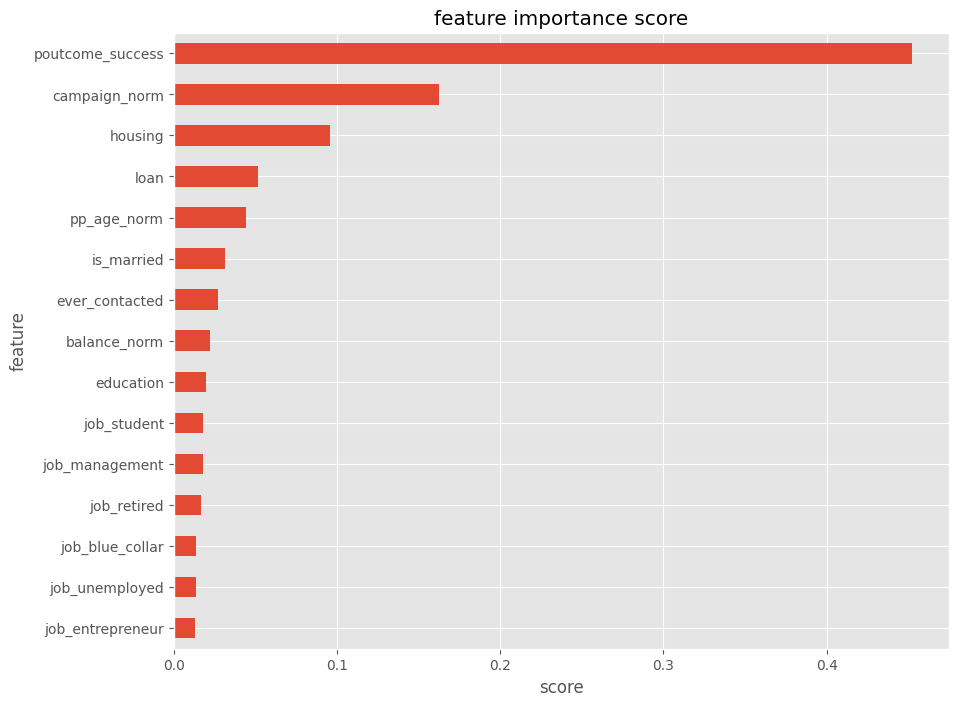

In [ ]:
show_feature_importance(xg)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import numpy as np

#Menjadikan ke dalam bentuk dictionary
hyperparameters = {
                    'max_depth' : [int(x) for x in np.linspace(6, 110, num = 11)],
                    'min_child_weight' : [int(x) for x in np.linspace(1, 20, num = 11)],
                    'gamma' : [float(x) for x in np.linspace(0, 1, num = 11)],
                    'tree_method' : ['auto', 'exact', 'approx', 'hist'],

                    'colsample_bytree' : [float(x) for x in np.linspace(0, 1, num = 11)],
                    'eta' : [float(x) for x in np.linspace(0, 1, num = 100)],

                    'lambda' : [float(x) for x in np.linspace(0, 1, num = 11)],
                    'alpha' : [float(x) for x in np.linspace(0, 1, num = 11)]
                    }

# Init
from xgboost import XGBClassifier
xg = XGBClassifier(random_state=42)
xg_tuned = RandomizedSearchCV(xg, hyperparameters, cv=5, random_state=42, scoring='recall')
xg_tuned.fit(X_train,y_train)

# Predict & Evaluation
eval_classification(xg_tuned)

Accuracy (Test Set): 0.88
Precision (Test Set): 0.90
Recall (Test Set): 0.72
F1-Score (Test Set): 0.80
roc_auc (test-proba): 0.91
roc_auc (train-proba): 0.95


Setelah dilakukan hyperparameter tuning dapat dilihat bahwa hasil score meningkat dan tidak terjadi overfit

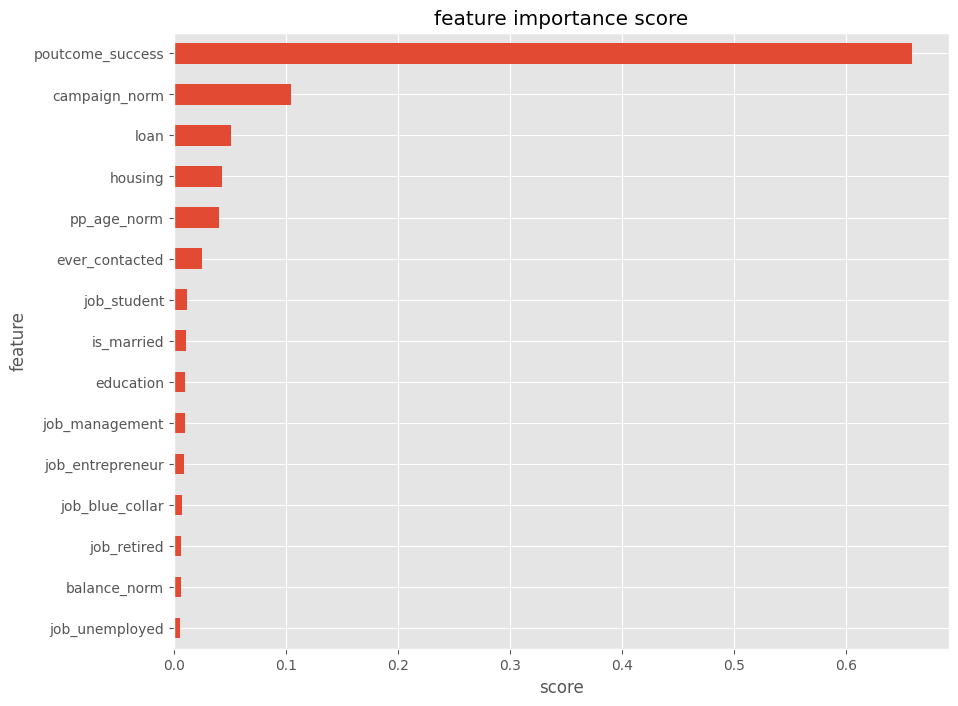

In [ ]:
show_feature_importance(xg_tuned.best_estimator_)

## Adaboost

AdaBoost

Menggunakan model ML AdaBoost, tampilkan hasil classification pertamanya.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier(random_state=42)
ab.fit(X_train, y_train)
eval_classification(ab)

Accuracy (Test Set): 0.79
Precision (Test Set): 0.83
Recall (Test Set): 0.48
F1-Score (Test Set): 0.61
roc_auc (test-proba): 0.80
roc_auc (train-proba): 0.80


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import numpy as np

# List of hyperparameter
hyperparameters = dict(n_estimators = [int(x) for x in np.linspace(start = 50, stop = 500, num = 500)], # Jumlah iterasi
                       learning_rate = [float(x) for x in np.linspace(start = 0.001, stop = 0.1, num = 200)],
                       algorithm = ['SAMME','SAMME.R']
                      )

# Init model
ab = AdaBoostClassifier(random_state=42)
ab_tuned = RandomizedSearchCV(ab, hyperparameters, random_state=42, cv=5, scoring='recall')
ab_tuned.fit(X_train ,y_train)

# Predict & Evaluation
eval_classification(ab_tuned)

Accuracy (Test Set): 0.77
Precision (Test Set): 0.87
Recall (Test Set): 0.36
F1-Score (Test Set): 0.51
roc_auc (test-proba): 0.79
roc_auc (train-proba): 0.79


Setelah dilakukan hyperparameter tuning nilai recall menurun

# Shap Decision Tree

In [ ]:
!pip install shap

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
import shap

explainer = shap.TreeExplainer(dt)
shap_values = explainer.shap_values(X_test)

print(type(shap_values))
if isinstance(shap_values, list):
    print("Jumlah kelas:", len(shap_values))
    print("shap_values[0].shape:", shap_values[0].shape)
    print("shap_values[1].shape:", shap_values[1].shape)
else:
    print("shap_values.shape:", shap_values.shape)

print("X_test.shape:", X_test.shape)

<class 'numpy.ndarray'>
shap_values.shape: (11663, 15, 2)
X_test.shape: (11663, 15)


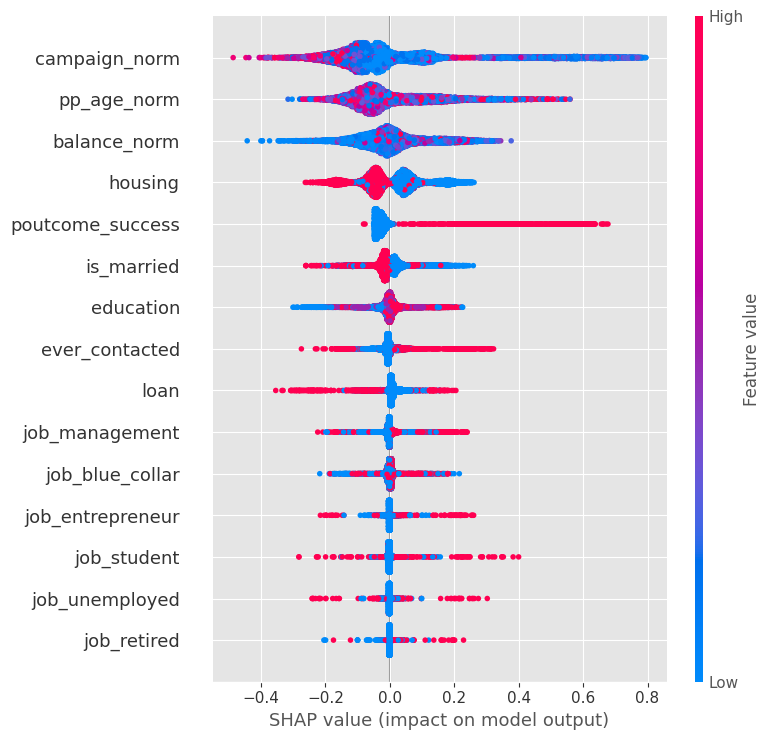

In [ ]:
# Ambil shap value untuk kelas 1 (positif)
shap_values_class1 = shap_values[:, :, 1]

# Buat summary plot
shap.summary_plot(shap_values_class1, X_test)


In [ ]:
shap.initjs()

# SHAP values untuk sample ke-0 dan kelas 1
sample_index = 0
shap_values_for_sample = shap_values[sample_index, :, 1]

# Force plot
shap.force_plot(explainer.expected_value[1], shap_values_for_sample, X_test.iloc[sample_index, :])